In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib

print("Libraries ready!")

Libraries ready!


In [2]:
iris = load_iris()

print("Dataset loaded!")
print("Features:", iris.feature_names)
print("Classes:", iris.target_names)

Dataset loaded!
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


In [3]:
X = iris.data
y = iris.target

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (150, 4)
Output shape: (150,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


In [5]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

print("Model created!")

Model created!


In [6]:
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [7]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


In [8]:
joblib.dump(model, "iris_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [10]:
new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_flower)

print("Predicted Species:", iris.target_names[prediction[0]])

Predicted Species: setosa


In [11]:
new_flower = [[6.2, 2.9, 4.3, 1.3]]

prediction = model.predict(new_flower)

print("Predicted Species:", iris.target_names[prediction[0]])

Predicted Species: versicolor


In [12]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


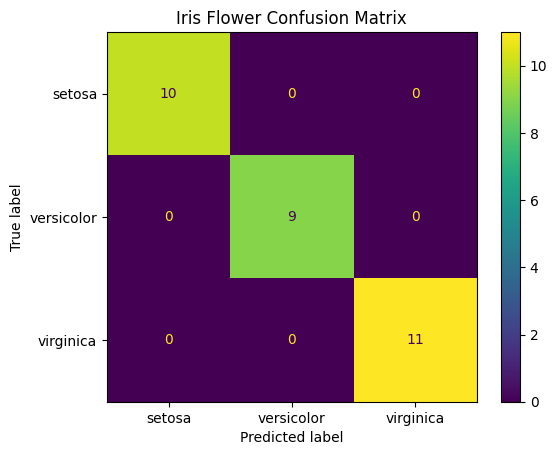

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=iris.target_names
)

plt.title("Iris Flower Confusion Matrix")
plt.show()

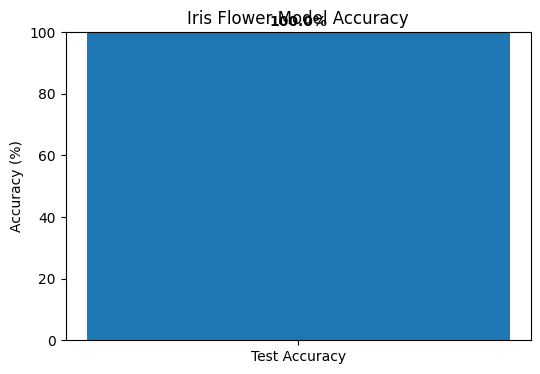

In [14]:
accuracy_percent = accuracy * 100

plt.figure(figsize=(6, 4))
plt.bar(["Test Accuracy"], [accuracy_percent])

plt.ylim(0, 100)
plt.ylabel("Accuracy (%)")
plt.title("Iris Flower Model Accuracy")
plt.text(0, accuracy_percent + 2, f"{accuracy_percent:.1f}%",
         ha="center", fontweight="bold")

plt.show()

Validation Accuracy for each fold:
[0.96666667 0.96666667 0.93333333 0.96666667 1.        ]
Average Validation Accuracy: 0.9666666666666668


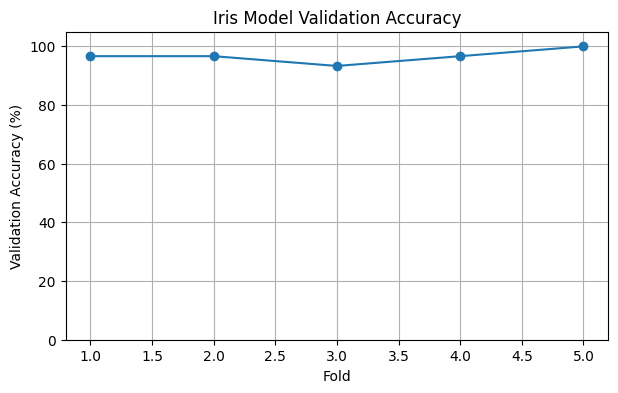

In [15]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Validation Accuracy for each fold:")
print(cv_scores)

print("Average Validation Accuracy:",
      cv_scores.mean())

plt.figure(figsize=(7, 4))
plt.plot(
    range(1, 6),
    cv_scores * 100,
    marker='o'
)

plt.xlabel("Fold")
plt.ylabel("Validation Accuracy (%)")
plt.title("Iris Model Validation Accuracy")
plt.ylim(0, 105)
plt.grid(True)
plt.show()

In [16]:
print("Ready for proper ML model training!")

Ready for proper ML model training!


In [17]:
from sklearn.model_selection import train_test_split

# 70% Training, 30% Temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# 15% Validation, 15% Testing
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training data:", X_train.shape)
print("Validation data:", X_val.shape)
print("Testing data:", X_test.shape)

Training data: (105, 4)
Validation data: (22, 4)
Testing data: (23, 4)


In [18]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [19]:
from sklearn.metrics import accuracy_score

y_val_pred = model.predict(X_val)

val_accuracy = accuracy_score(y_val, y_val_pred)

print("Validation Accuracy:", val_accuracy)
print("Validation Accuracy (%):", val_accuracy * 100)

Validation Accuracy: 0.8636363636363636
Validation Accuracy (%): 86.36363636363636


In [20]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [2, 3, 4, 5, None],
    'min_samples_split': [2, 3, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'max_depth': 2, 'min_samples_split': 2, 'n_estimators': 150}
Best Cross-Validation Accuracy: 0.9619047619047618


In [21]:
best_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=2,
    min_samples_split=2,
    random_state=42
)

best_model.fit(X_train, y_train)

print("Best model trained successfully!")

Best model trained successfully!


In [22]:
y_test_pred = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)

print("Final Test Accuracy:", test_accuracy)
print("Final Test Accuracy (%):", test_accuracy * 100)

Final Test Accuracy: 0.9565217391304348
Final Test Accuracy (%): 95.65217391304348


In [23]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_test_pred,
    target_names=iris.target_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         7
  versicolor       0.89      1.00      0.94         8
   virginica       1.00      0.88      0.93         8

    accuracy                           0.96        23
   macro avg       0.96      0.96      0.96        23
weighted avg       0.96      0.96      0.96        23



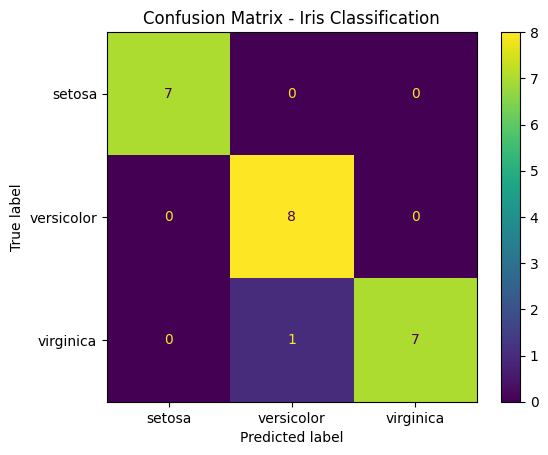

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=iris.target_names
)

plt.title("Confusion Matrix - Iris Classification")
plt.show()

Fold-wise Validation Accuracy:
Fold 1: 95.24%
Fold 2: 95.24%
Fold 3: 100.00%
Fold 4: 90.48%
Fold 5: 100.00%
Mean Validation Accuracy: 96.19047619047618


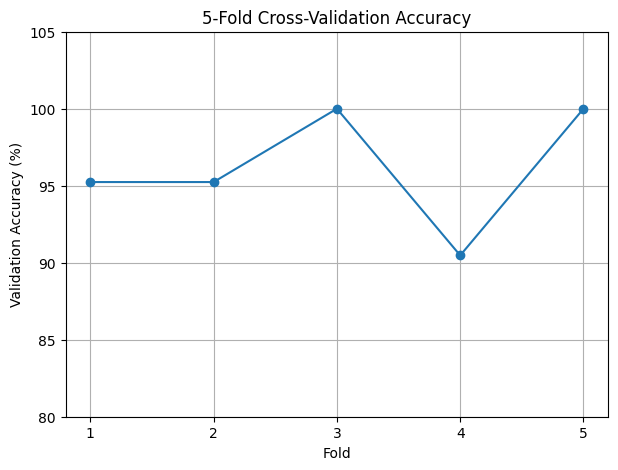

In [25]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Fold-wise Validation Accuracy:")
for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: {score * 100:.2f}%")

print("Mean Validation Accuracy:", cv_scores.mean() * 100)

plt.figure(figsize=(7, 5))
plt.plot(
    range(1, 6),
    cv_scores * 100,
    marker='o'
)

plt.xlabel("Fold")
plt.ylabel("Validation Accuracy (%)")
plt.title("5-Fold Cross-Validation Accuracy")
plt.xticks(range(1, 6))
plt.ylim(80, 105)
plt.grid(True)
plt.show()

In [26]:
import joblib

joblib.dump(best_model, "iris_model.pkl")

print("Final Iris ML Model saved successfully!")

Final Iris ML Model saved successfully!


In [27]:
# New flower measurements
new_flower = [[5.1, 3.5, 1.4, 0.2]]

# Prediction
prediction = best_model.predict(new_flower)

print("Predicted Flower:", iris.target_names[prediction[0]])

Predicted Flower: setosa


In [28]:
probability = best_model.predict_proba(new_flower)[0]

for name, prob in zip(iris.target_names, probability):
    print(f"{name}: {prob * 100:.2f}%")

setosa: 99.60%
versicolor: 0.40%
virginica: 0.00%


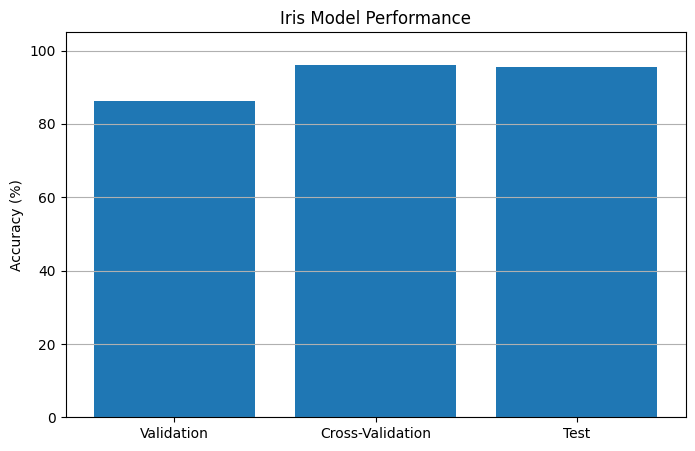

In [29]:
import matplotlib.pyplot as plt

validation_accuracy = val_accuracy * 100
cv_accuracy = grid_search.best_score_ * 100
test_accuracy_percent = test_accuracy * 100

labels = [
    "Validation",
    "Cross-Validation",
    "Test"
]

values = [
    validation_accuracy,
    cv_accuracy,
    test_accuracy_percent
]

plt.figure(figsize=(8, 5))
plt.bar(labels, values)

plt.ylabel("Accuracy (%)")
plt.title("Iris Model Performance")
plt.ylim(0, 105)
plt.grid(axis="y")
plt.show()

In [30]:
import joblib

# Load saved final model
loaded_model = joblib.load("iris_model.pkl")

# Test prediction
test_flower = [[6.2, 2.9, 4.3, 1.3]]

prediction = loaded_model.predict(test_flower)

print("Loaded Model Prediction:", iris.target_names[prediction[0]])

Loaded Model Prediction: versicolor


In [31]:
from IPython.display import display
import ipywidgets as widgets

sepal_length = widgets.FloatText(description="Sepal Length:")
sepal_width = widgets.FloatText(description="Sepal Width:")
petal_length = widgets.FloatText(description="Petal Length:")
petal_width = widgets.FloatText(description="Petal Width:")

button = widgets.Button(description="Predict Flower")

output = widgets.Output()

def predict_flower(b):
    with output:
        output.clear_output()

        flower = [[
            sepal_length.value,
            sepal_width.value,
            petal_length.value,
            petal_width.value
        ]]

        prediction = loaded_model.predict(flower)[0]
        probability = loaded_model.predict_proba(flower)[0]

        print("🌸 Predicted Flower:", iris.target_names[prediction])
        print(f"Confidence: {probability[prediction] * 100:.2f}%")

button.on_click(predict_flower)

display(
    sepal_length,
    sepal_width,
    petal_length,
    petal_width,
    button,
    output
)

FloatText(value=0.0, description='Sepal Length:')

FloatText(value=0.0, description='Sepal Width:')

FloatText(value=0.0, description='Petal Length:')

FloatText(value=0.0, description='Petal Width:')

Button(description='Predict Flower', style=ButtonStyle())

Output()

In [32]:
print("========== IRIS FLOWER CLASSIFICATION ==========")
print("Algorithm: Random Forest Classifier")
print("Dataset: Iris Dataset")
print("Number of Samples:", len(X))
print("Number of Features:", X.shape[1])
print("Classes:", list(iris.target_names))

print("\n--- Model Performance ---")
print(f"Validation Accuracy: {validation_accuracy:.2f}%")
print(f"Cross-Validation Accuracy: {cv_accuracy:.2f}%")
print(f"Final Test Accuracy: {test_accuracy_percent:.2f}%")

print("\n--- Model Status ---")
print("Model saved as: iris_model.pkl")
print("Prediction Interface: Working")
print("Project Status: Completed Successfully ✅")

========== IRIS FLOWER CLASSIFICATION ==========
Algorithm: Random Forest Classifier
Dataset: Iris Dataset
Number of Samples: 150
Number of Features: 4
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

--- Model Performance ---
Validation Accuracy: 86.36%
Cross-Validation Accuracy: 96.19%
Final Test Accuracy: 95.65%

--- Model Status ---
Model saved as: iris_model.pkl
Prediction Interface: Working
Project Status: Completed Successfully ✅


In [33]:
from google.colab import files

files.download("iris_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>